<a href="https://colab.research.google.com/github/meenakshi930/DiseaseLeafClassifier/blob/anshika-data/Anshika/notebooks/03_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disease Leaf Classifier — Image Preprocessing

## Objective

Prepare the cleaned leaf image dataset for machine learning model training.

### Preprocessing Tasks

- Load the clean image list
- Load the corresponding leaf images
- Resize images to a fixed size
- Convert images into a consistent format
- Normalize pixel values
- Verify the preprocessed images

## 1. Load Clean Image List

The cleaned dataset contains 20,624 valid and unique images across 15 classes.

The `clean_image_list.csv` file contains the class name and image filename for each valid image.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving clean_image_list.csv to clean_image_list.csv


In [2]:
import pandas as pd

clean_df = pd.read_csv("clean_image_list.csv")

print("Number of images:", len(clean_df))
print("\nColumns:")
print(clean_df.columns.tolist())

print("\nFirst 5 rows:")
print(clean_df.head())

Number of images: 20624

Columns:
['class_name', 'image_name']

First 5 rows:
                      class_name  \
0  Pepper__bell___Bacterial_spot   
1  Pepper__bell___Bacterial_spot   
2  Pepper__bell___Bacterial_spot   
3  Pepper__bell___Bacterial_spot   
4  Pepper__bell___Bacterial_spot   

                                          image_name  
0  0f72db9c-d635-4415-9781-68937328aed2___NREC_B....  
1  1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B....  
2  b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Sp...  
3  e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Sp...  
4  8b50f2db-cbf2-4758-bea6-a011f0cc1497___JR_B.Sp...  


In [3]:
import os
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")

plantvillage_path = os.path.join(path, "PlantVillage")

print("PlantVillage path:", plantvillage_path)
print("Exists:", os.path.exists(plantvillage_path))

Using Colab cache for faster access to the 'plantdisease' dataset.
PlantVillage path: /kaggle/input/plantdisease/PlantVillage
Exists: True


In [4]:
from PIL import Image
import os

first_class = clean_df.iloc[0]["class_name"]
first_image = clean_df.iloc[0]["image_name"]

first_image_path = os.path.join(
    plantvillage_path,
    first_class,
    first_image
)

print("Image path:")
print(first_image_path)

print("\nFile exists:", os.path.exists(first_image_path))

if os.path.exists(first_image_path):
    image = Image.open(first_image_path)
    print("Image size:", image.size)
    print("Image mode:", image.mode)

Image path:
/kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG

File exists: True
Image size: (256, 256)
Image mode: RGB


In [5]:
IMG_SIZE = (224, 224)

resized_image = image.resize(IMG_SIZE)

print("Original size:", image.size)
print("Resized size:", resized_image.size)

Original size: (256, 256)
Resized size: (224, 224)


In [6]:
import numpy as np

image_array = np.array(resized_image)

normalized_image = image_array / 255.0

print("Before normalization:")
print("Minimum:", image_array.min())
print("Maximum:", image_array.max())

print("\nAfter normalization:")
print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())
print("Shape:", normalized_image.shape)

Before normalization:
Minimum: 0
Maximum: 255

After normalization:
Minimum: 0.0
Maximum: 1.0
Shape: (224, 224, 3)


In [7]:
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = np.array(image)
    image_array = image_array / 255.0

    return image_array

In [8]:
processed_image = preprocess_image(first_image_path)

print("Processed image shape:", processed_image.shape)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())

Processed image shape: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [9]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


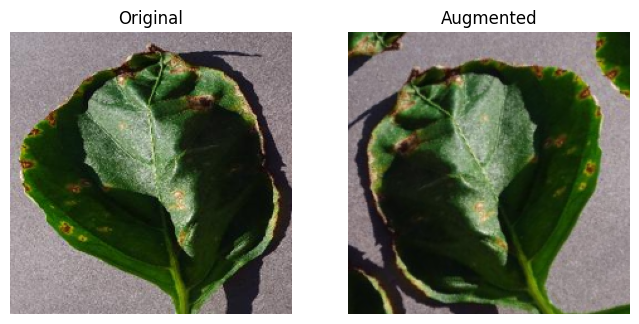

In [10]:
import matplotlib.pyplot as plt

original = preprocess_image(first_image_path)

augmented = data_augmentation(
    tf.expand_dims(original, axis=0),
    training=True
)

augmented = augmented[0].numpy()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title("Augmented")
plt.axis("off")

plt.show()

In [11]:
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = np.array(image, dtype=np.float32)
    image_array = image_array / 255.0

    return image_array

In [12]:
sample_size = 5

for i in range(sample_size):
    class_name = clean_df.iloc[i]["class_name"]
    image_name = clean_df.iloc[i]["image_name"]

    image_path = os.path.join(
        plantvillage_path,
        class_name,
        image_name
    )

    processed = preprocess_image(image_path)

    print(f"Image {i + 1}")
    print("Class:", class_name)
    print("Shape:", processed.shape)
    print("Min:", processed.min())
    print("Max:", processed.max())
    print()

Image 1
Class: Pepper__bell___Bacterial_spot
Shape: (224, 224, 3)
Min: 0.0
Max: 1.0

Image 2
Class: Pepper__bell___Bacterial_spot
Shape: (224, 224, 3)
Min: 0.0
Max: 1.0

Image 3
Class: Pepper__bell___Bacterial_spot
Shape: (224, 224, 3)
Min: 0.0
Max: 0.98039216

Image 4
Class: Pepper__bell___Bacterial_spot
Shape: (224, 224, 3)
Min: 0.0
Max: 0.95686275

Image 5
Class: Pepper__bell___Bacterial_spot
Shape: (224, 224, 3)
Min: 0.0
Max: 0.98039216



## Preprocessing Summary

The cleaned PlantVillage image list was used to define the preprocessing pipeline.

### Preprocessing Steps

1. **RGB Conversion**
   - All images are converted to RGB format.
   - This ensures a consistent 3-channel input.

2. **Image Resizing**
   - Original images: 256 × 256 pixels
   - Resized images: 224 × 224 pixels

3. **Pixel Normalization**
   - Pixel values are converted from the range 0–255 to approximately 0–1.
   - This produces floating-point input suitable for neural-network processing.

4. **Data Augmentation**
   - Random horizontal flipping
   - Random rotation
   - Random zoom
   - Augmentation is applied dynamically during training rather than creating permanent duplicate images.

### Verification

The preprocessing pipeline was tested on multiple images.

Each processed image produced:

`(224, 224, 3)`

with normalized pixel values in the range:

`0.0 to 1.0`

### Conclusion

The preprocessing pipeline successfully prepares the cleaned leaf images for CNN-based classification while keeping the original dataset unchanged.